# Random Forest Model

Training a Random Forest classifier for predicting on-time delivery.

In [9]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/final_cleaned_data.csv')
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Data prepared for Random Forest')

Data prepared for Random Forest


In [10]:
import numpy as np

# Clean train data
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(X_train.mean())

# Clean test data
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(X_test.mean())

In [11]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
print('Random Forest trained')

Random Forest trained


In [12]:
# Evaluate
y_pred = rf_model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.6713636363636364

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.90      0.69       887
           1       0.89      0.51      0.65      1313

    accuracy                           0.67      2200
   macro avg       0.72      0.71      0.67      2200
weighted avg       0.75      0.67      0.67      2200



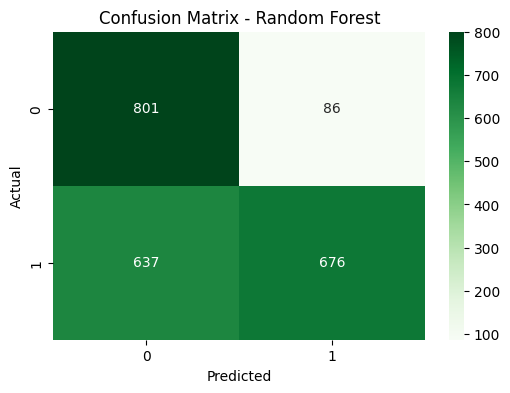

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

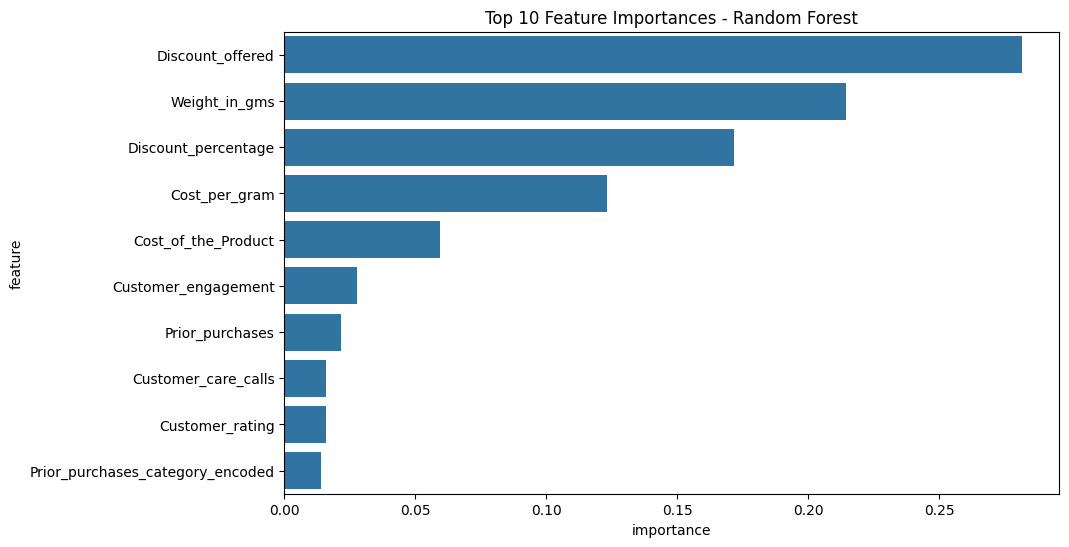

In [14]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

In [15]:
# Save model
joblib.dump(rf_model, '../models/random_forest.pkl')
print('Random Forest model saved')

Random Forest model saved
